In [22]:
import os
import pandas as pd
import numpy as np

In [23]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [ ]:
results_dir = f"/hdd/ivny/direct_qa_in_domain_calibration_top_k_ablation"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    "_/hdd/ivny/direct_qa_in_domain_calibration_top_k_ablation/1/truthful_qa/meta-llama/Llama-3.1-8B-Instruct"
    _, _, _, _, top_k, dataset_name, model_fam, model_name = leaf_dir.split("/")
    if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
        csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
        csv_records = csv_data.transpose().to_dict("records")

        for record in csv_records:
            record["model"] = model_name_map.get(model_name, model_name)
            record["top_k"] = int(top_k.split("top_")[1])

        all_records.extend(csv_records)
    else:
        print(model_name, top_k, "missing calibration_performance.csv")

In [25]:
pd.DataFrame(all_records)[["top_k", 
                           "original_lc_generalised_ECE", "original_lc_faithfulness_divergence",
                           "calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_lc_rewritten_lc_faithfulness_divergence",
                           "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_faithfulness_divergence",
                           "calibrated_su_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_faithfulness_divergence",
                           ]]

,top_k,original_lc_generalised_ECE,original_lc_faithfulness_divergence,calibrated_lc_rewritten_lc_generalised_ECE,calibrated_lc_rewritten_lc_faithfulness_divergence,calibrated_tp_rewritten_lc_generalised_ECE,calibrated_tp_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence
0,5,0.357561,2.100883,0.209712,0.680113,0.178698,0.574490,0.217338,0.722535
1,20,0.357442,2.100883,0.210350,0.742392,0.191140,0.642041,0.217949,0.713553
2,1,0.357435,2.100883,0.243445,0.831385,0.201259,0.621087,0.235760,0.779052
3,15,0.357624,2.100883,0.209638,0.674966,0.189451,0.607118,0.210812,0.747240
4,25,0.357762,2.100883,0.213261,0.683659,0.184586,0.599460,0.219645,0.728458
5,3,0.357598,2.100883,0.211961,0.692920,0.186602,0.574239,0.218633,0.765988
6,10,0.357829,2.100883,0.200374,0.672622,0.186511,0.590766,0.212899,0.715296


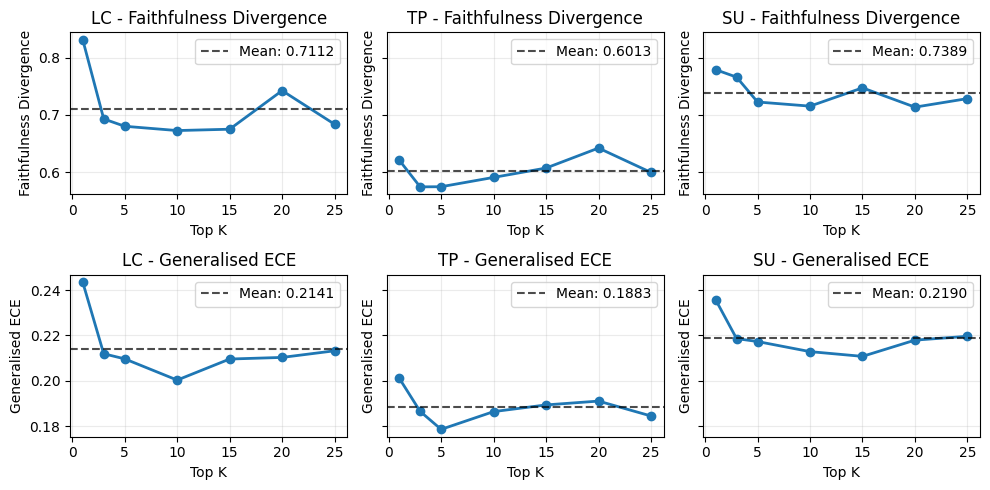

In [26]:
import matplotlib.pyplot as plt

df = pd.DataFrame(all_records).copy()

method_cfg = {
    "LC": {
        "fd_col": "calibrated_lc_rewritten_lc_faithfulness_divergence",
        "ece_col": "calibrated_lc_rewritten_lc_generalised_ECE",
    },
    "TP": {
        "fd_col": "calibrated_tp_rewritten_lc_faithfulness_divergence",
        "ece_col": "calibrated_tp_rewritten_lc_generalised_ECE",
    },
    "SU": {
        "fd_col": "calibrated_su_rewritten_lc_faithfulness_divergence",
        "ece_col": "calibrated_su_rewritten_lc_generalised_ECE",
    },
}

fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=False, sharey='row')

for col_idx, (method_name, cols) in enumerate(method_cfg.items()):
    # Aggregate over all records at each top_k to produce one line per subplot.
    agg = (
        df.groupby("top_k", as_index=False)[[cols["fd_col"], cols["ece_col"]]]
        .mean()
        .sort_values("top_k")
    )

    # Top row: Faithfulness Divergence
    ax_fd = axes[0, col_idx]
    ax_fd.plot(agg["top_k"], agg[cols["fd_col"]], marker="o", linewidth=2)
    fd_mean = agg[cols["fd_col"]].mean()
    ax_fd.axhline(fd_mean, linestyle="--", linewidth=1.5, color="black", alpha=0.7, label=f"Mean: {fd_mean:.4f}")
    ax_fd.set_title(f"{method_name} - Faithfulness Divergence")
    ax_fd.set_xlabel("Top K")
    ax_fd.set_ylabel("Faithfulness Divergence")
    ax_fd.legend(loc="upper right")
    ax_fd.grid(alpha=0.25)

    # Bottom row: Generalised ECE
    ax_ece = axes[1, col_idx]
    ax_ece.plot(agg["top_k"], agg[cols["ece_col"]], marker="o", linewidth=2)
    ece_mean = agg[cols["ece_col"]].mean()
    ax_ece.axhline(ece_mean, linestyle="--", linewidth=1.5, color="black", alpha=0.7, label=f"Mean: {ece_mean:.4f}")
    ax_ece.set_title(f"{method_name} - Generalised ECE")
    ax_ece.set_xlabel("Top K")
    ax_ece.set_ylabel("Generalised ECE")
    ax_ece.legend(loc="upper right")
    ax_ece.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("top_k_ablation_results.pdf", dpi=300, bbox_inches='tight')